<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


<h1>Differentiation in PyTorch</h1> 


<h2>Objective</h2><ul><li> How to perform differentiation in pytorch.</li></ul> 


<h2>Table of Contents</h2>

<p>In this lab, you will learn the basics of differentiation.</p> 

<ul>
    <li><a href="#Derivative">Derivatives</a></li>
    <li><a href="#Partial_Derivative">Partial Derivatives</a></li>
</ul>

<p>Estimated Time Needed: <strong>25 min</strong></p>
<hr>


<h2>Preparation</h2>


The following are the libraries we are going to use for this lab.


In [ ]:
# All the necessary library checks, installs, etc. are handled in TorchTensors1D.ipynb
'''
'%%time
%pip install matplotlib
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu
'''

In [17]:
# These are the libraries will be useing for this lab.

import torch 
import matplotlib.pylab as plt


<!--Empty Space for separating topics-->


<a name="Derivative"><h2 id="Derivative">Derivatives</h2></a>


In [ ]:
# This cell has nothing to do with the course. I included it here because it is a good example of
# calculating and understanding derivatives without using PyTorch (djb - 28 Dec 25)

from sympy import *
# Declare x to sympy
x, s = symbols('x s')

# Declare function f to square x
f = x**2

# Calculate the derivative of the function
dx_f = diff(f)

print(dx_f)

# Use limits to calculate the slope for a slope between two points with a gap of "s" by substituting into rise over run formula.
slope_f = (f.subs(x, x + s) - f) / ((x + s) - x)
print(slope_f)



In [12]:
# This cell has nothing to do with the course. I included it here because it is a good example of
# calculating and understanding derivatives without using PyTorch (djb - 28 Dec 25)
#
# Use gradient descent to find the minimum of a parabola

import random


def f(x):
    return (x - 3) ** 2 + 4


def dx_f(x):
    return 2 * (x - 3)


# Set the learning rate
L = .0001

# Number of iterations to perform gradient descent
iterations = 100000

# Start at a random x
x = random.randint(-15, 15)

for i in range(iterations):
    # Get slope
    d_x = dx_f(x)

    # Update x by subtracting the learning rate * slope
    x -= L * d_x

#print(f"{x:.2f}", f(x))
print("{0:.2f} {1}".format(x, f(x)))



3.00 4.000000000000001


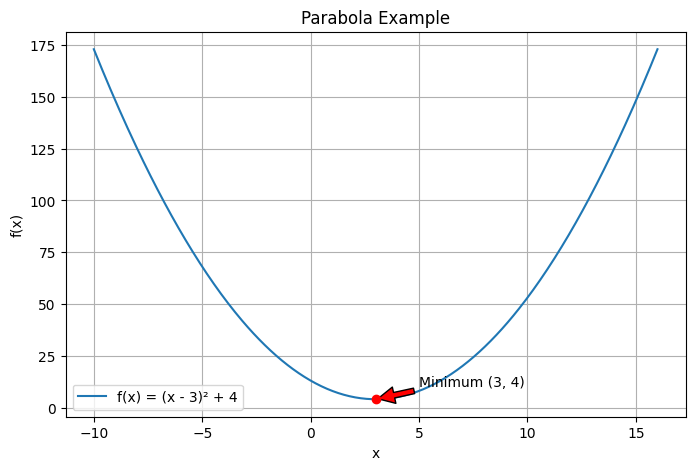

In [13]:
# This example has nothing to do with PyTorch or the course directly.
# It demonstrates how to understand functions and derivatives visually,
# using plain Python, NumPy, and plotting. Note there is no use of derivatives in this cell.
# (djb - 28 Dec 25)

import matplotlib.pyplot as plt   # Library for plotting graphs
import numpy as np                # Library for numerical operations

# ------------------------------------------------------------
# Define a mathematical function
#
# f(x) = (x - 3)^2 + 4
#
# This is a quadratic function (a parabola).
# It has a single minimum point (its lowest value).
# ------------------------------------------------------------
def f(x):
    return (x - 3)**2 + 4

# ------------------------------------------------------------
# Create a range of x-values
#
# linspace(start, end, num_points)
# Generates evenly spaced numbers between start and end.
#
# Here:
# - x goes from -10 to 16
# - 400 points gives a smooth curve when plotted
# ------------------------------------------------------------
x = np.linspace(-10, 16, 400)

# ------------------------------------------------------------
# Compute the corresponding y-values
#
# NumPy applies the function f(x) to every value in x.
# This produces a new array y, where:
#   y[i] = f(x[i])
# ------------------------------------------------------------
y = f(x)

# ------------------------------------------------------------
# Create the plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))        # Set the size of the figure
plt.plot(x, y, label='f(x) = (x - 3)² + 4')  # Plot the function

# Add labels and title to explain the plot
plt.title('Parabola Example')
plt.xlabel('x')
plt.ylabel('f(x)')

# Add a grid to make reading values easier
plt.grid(True)

# Show the legend (uses the label from plt.plot)
plt.legend()

# ------------------------------------------------------------
# Highlight the minimum point of the function
#
# For this function, the minimum occurs at:
#   x = 3
#   f(3) = 4
#
# This point is important because:
# - The slope (derivative) is zero here
# - It represents a minimum, similar to a minimum loss in ML
# ------------------------------------------------------------
plt.scatter(3, f(3), color='red', zorder=5, label='Minimum (3, 4)')

# Add an arrow and text pointing to the minimum
plt.annotate(
    'Minimum (3, 4)',     # Text to display
    xy=(3, 4),            # Point being annotated
    xytext=(5, 10),       # Where the text appears
    arrowprops=dict(facecolor='red', shrink=0.05)
)

# ------------------------------------------------------------
# Display the final plot
# ------------------------------------------------------------
plt.show()


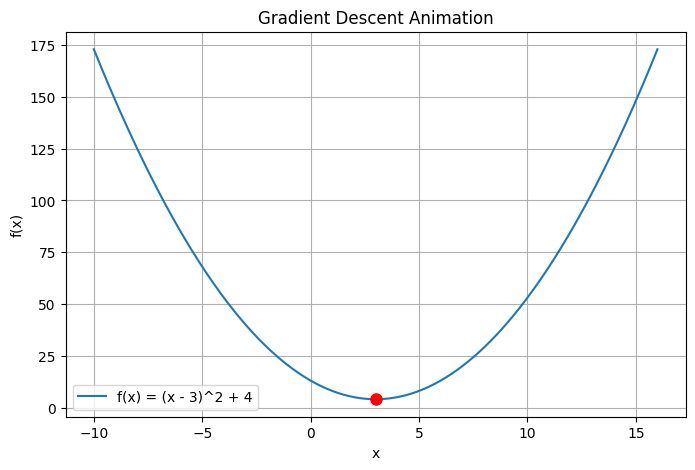

In [11]:
# Gradient descent behaves like a damped physical system:
# If x overshoots the minimum, the sign of the gradient flips,
# causing the update to move in the opposite direction.
# This is analogous to a pendulum oscillating around equilibrium
# with smaller and smaller swings until it settles at rest.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def f(x):
    return (x - 3)**2 + 4

def df(x):
    return 2 * (x - 3)

x_vals = np.linspace(-10, 16, 400)
y_vals = f(x_vals)

x_current = -8.0
learning_rate = 0.1

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_vals, y_vals, label="f(x) = (x - 3)^2 + 4")
point, = ax.plot([], [], 'ro', markersize=8)
ax.set_title("Gradient Descent Animation")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.grid(True)
ax.legend()

def init():
    point.set_data([x_current], [f(x_current)])
    return (point,)

def update(frame):
    global x_current

    # ---- GRADIENT DESCENT STEP ----
    # Update x by moving it downhill in the direction of the negative gradient.
    # This is the core optimization step:
    #   x_new = x_old - learning_rate * (df/dx at x_old)
    x_current = x_current - learning_rate * df(x_current)

    # Update the plotted point to reflect the new x position
    point.set_data([x_current], [f(x_current)])
    return (point,)

# The call to update performs the gradient descent
ani = FuncAnimation(fig, update, init_func=init, frames=40, interval=200, blit=True)

HTML(ani.to_jshtml())


Let us create the tensor <code>x</code> and set the parameter <code>requires_grad</code> to true because you are going to take the derivative of the tensor.


In [15]:
# Create a tensor x

x = torch.tensor(2.0, requires_grad = True)
print("The tensor x: ", x)

The tensor x:  tensor(2., requires_grad=True)


Then let us create a tensor according to the equation $ y=x^2 $.


In [20]:
# Create a tensor y according to y = x^2

y = x ** 2
print("The result of y = x^2: ", y)

The result of y = x^2:  tensor(4., grad_fn=<PowBackward0>)


Then let us take the derivative with respect x at x = 2


In [22]:
# Take the derivative. Try to print out the derivative at the value x = 2

y.backward()
print("The dervative at x = 2: ", x.grad)

The dervative at x = 2:  tensor(8.)


The preceding lines perform the following operation: 


$\frac{\mathrm{dy(x)}}{\mathrm{dx}}=2x$


$\frac{\mathrm{dy(x=2)}}{\mathrm{dx}}=2(2)=4$


In [21]:
print('data:',x.data)
print('grad_fn:',x.grad_fn)
print('grad:',x.grad)
print("is_leaf:",x.is_leaf)
print("requires_grad:",x.requires_grad)

data: tensor(2.)
grad_fn: None
grad: tensor(4.)
is_leaf: True
requires_grad: True


In [ ]:
print('data:',y.data)
print('grad_fn:',y.grad_fn)
print('grad:',y.grad)
print("is_leaf:",y.is_leaf)
print("requires_grad:",y.requires_grad)

Let us try to calculate the derivative for a more complicated function. 


In [ ]:
# Calculate the y = x^2 + 2x + 1, then find the derivative 

x = torch.tensor(2.0, requires_grad = True)
y = x ** 2 + 2 * x + 1
print("The result of y = x^2 + 2x + 1: ", y)
y.backward()
print("The dervative at x = 2: ", x.grad)

The function is in the following form:
$y=x^{2}+2x+1$


The derivative is given by:


$\frac{\mathrm{dy(x)}}{\mathrm{dx}}=2x+2$

$\frac{\mathrm{dy(x=2)}}{\mathrm{dx}}=2(2)+2=6$


<!--Empty Space for separating topics-->


<h3>Practice</h3>


Determine the derivative of $ y = 2x^3+x $ at $x=1$


In [ ]:
# Practice: Calculate the derivative of y = 2x^3 + x at x = 1

# Type your code here

Double-click <b>here</b> for the solution.
<!-- 
x = torch.tensor(1.0, requires_grad=True)
y = 2 * x ** 3 + x
y.backward()
print("The derivative result: ", x.grad)
 -->


<!--Empty Space for separating topics-->


 We can implement our own custom autograd Functions by subclassing
    torch.autograd.Function and implementing the forward and backward passes
    which operate on Tensors


In [ ]:
class SQ(torch.autograd.Function):


    @staticmethod
    def forward(ctx,i):
        """
        In the forward pass we receive a Tensor containing the input and return
        a Tensor containing the output. ctx is a context object that can be used
        to stash information for backward computation. You can cache arbitrary
        objects for use in the backward pass using the ctx.save_for_backward method.
        """
        result=i**2
        ctx.save_for_backward(i)
        return result

    @staticmethod
    def backward(ctx, grad_output):
        """
        In the backward pass we receive a Tensor containing the gradient of the loss
        with respect to the output, and we need to compute the gradient of the loss
        with respect to the input.
        """
        i, = ctx.saved_tensors
        grad_output = 2*i
        return grad_output

We can apply it the function  


In [ ]:
x=torch.tensor(2.0,requires_grad=True )
sq=SQ.apply

y=sq(x)
y
print(y.grad_fn)
y.backward()
x.grad

<a name="Partial_Derivative"><h2 id="Partial_Derivative">Partial Derivatives</h2></a>


We can also calculate <b>Partial Derivatives</b>. Consider the function: $f(u,v)=vu+u^{2}$


Let us create <code>u</code> tensor, <code>v</code> tensor and  <code>f</code> tensor


In [ ]:
# Calculate f(u, v) = v * u + u^2 at u = 1, v = 2

u = torch.tensor(1.0,requires_grad=True)
v = torch.tensor(2.0,requires_grad=True)
f = u * v + u ** 2
print("The result of v * u + u^2: ", f)

This is equivalent to the following: 


$f(u=1,v=2)=(2)(1)+1^{2}=3$


<!--Empty Space for separating topics-->


Now let us take the derivative with respect to <code>u</code>:


In [ ]:
# Calculate the derivative with respect to u

f.backward()
print("The partial derivative with respect to u: ", u.grad)

the expression is given by:


$\frac{\mathrm{\partial f(u,v)}}{\partial {u}}=v+2u$

$\frac{\mathrm{\partial f(u=1,v=2)}}{\partial {u}}=2+2(1)=4$


<!--Empty Space for separating topics-->


Now, take the derivative with respect to <code>v</code>:


In [ ]:
# Calculate the derivative with respect to v

print("The partial derivative with respect to u: ", v.grad)

The equation is given by:


$\frac{\mathrm{\partial f(u,v)}}{\partial {v}}=u$

$\frac{\mathrm{\partial f(u=1,v=2)}}{\partial {v}}=1$


<!--Empty Space for separating topics-->


Calculate the derivative with respect to a function with multiple values as follows. You use the sum trick to produce a scalar valued function and then take the gradient: 


In [ ]:
# Calculate the derivative with multiple values

x = torch.linspace(-10, 10, 10, requires_grad = True)
Y = x ** 2
y = torch.sum(x ** 2)

We can plot the function  and its derivative 


In [ ]:
# Take the derivative with respect to multiple value. Plot out the function and its derivative

y.backward()

plt.plot(x.detach().numpy(), Y.detach().numpy(), label = 'function')
plt.plot(x.detach().numpy(), x.grad.detach().numpy(), label = 'derivative')
plt.xlabel('x')
plt.legend()
plt.show()

The orange line is the slope of the blue line at the intersection point, which is the derivative of the blue line.


The  method <code> detach()</code>  excludes further tracking of operations in the graph, and therefore the subgraph will not record operations. This allows us to then convert the tensor to a numpy array. To understand the sum operation  <a href="https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html">Click Here</a>



<!--Empty Space for separating topics-->


The <b>relu</b> activation function is an essential function in neural networks. We can take the derivative as follows: 


In [ ]:
# Take the derivative of Relu with respect to multiple value. Plot out the function and its derivative

x = torch.linspace(-10, 10, 1000, requires_grad = True)
Y = torch.relu(x)
y = Y.sum()
y.backward()
plt.plot(x.detach().numpy(), Y.detach().numpy(), label = 'function')
plt.plot(x.detach().numpy(), x.grad.detach().numpy(), label = 'derivative')
plt.xlabel('x')
plt.legend()
plt.show()

<!--Empty Space for separating topics-->


In [ ]:
y.grad_fn

<h3>Practice</h3>


Try to determine partial derivative  $u$ of the following function where $u=2$ and $v=1$: $ f=uv+(uv)^2$


In [ ]:
# Practice: Calculate the derivative of f = u * v + (u * v) ** 2 at u = 2, v = 1

# Type the code here

Double-click __here__ for the solution.
<!-- 
u = torch.tensor(2.0, requires_grad = True)
v = torch.tensor(1.0, requires_grad = True)
f = u * v + (u * v) ** 2
f.backward()
print("The result is ", u.grad)
 -->


<a href="https://dataplatform.cloud.ibm.com/registration/stepone?utm_source=skills_network&utm_content=in_lab_content_link&utm_id=Lab-IBMDeveloperSkillsNetwork-DL0110EN-SkillsNetwork&context=cpdaas&apps=data_science_experience%2Cwatson_machine_learning"><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0110EN-SkillsNetwork/Template/module%201/images/Watson_Studio.png"></a>


<h2>About the Authors:</h2> 

<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


Other contributors: <a href="https://www.linkedin.com/in/michelleccarey/">Michelle Carey</a>, <a href="www.linkedin.com/in/jiahui-mavis-zhou-a4537814a">Mavis Zhou</a> 


<!--
## Change Log

|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2020-09-21  | 2.0  | Shubham  |  Migrated Lab to Markdown and added to course repo in GitLab |

-->


<hr>


## <h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>
